In [1]:
# import the necessary packages
import matplotlib.pyplot as plt
import numpy as np
import cv2 
import os
import imageio
import shutil

In [2]:

def calculate_blurriness_laplacian(image):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Calculate the Laplacian of the image
    laplacian = cv2.Laplacian(image, cv2.CV_64F)

    # Calculate the variance of the Laplacian
    variance_of_laplacian = laplacian.var()

    return variance_of_laplacian


def calculate_blurriness_fft(image):

    image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Apply Fourier Transform
    f = np.fft.fft2(image)
    fshift = np.fft.fftshift(f)
    magnitude_spectrum = np.abs(fshift)

    # Define a high frequency region by creating a mask with a high pass filter
    rows, cols = image.shape
    crow, ccol = rows // 2, cols // 2  # center

    # Create a mask first, center square is 1, remaining all zeros
    mask = np.ones((rows, cols), np.uint8)
    r = 30  # radius for low frequencies to be kept
    center = [crow, ccol]
    x, y = np.ogrid[:rows, :cols]
    mask_area = (x - center[0])**2 + (y - center[1])**2 <= r*r
    mask[mask_area] = 0

    # Apply mask and inverse DFT
    fshift = fshift * mask
    f_ishift = np.fft.ifftshift(fshift)
    img_back = np.fft.ifft2(f_ishift)
    img_back = np.abs(img_back)

    # Calculate the sum of the magnitudes of the high frequencies
    high_freq_sum = np.sum(magnitude_spectrum * mask)
    
    # Normalize the high frequency sum by the size of the image
    blurriness = high_freq_sum / (rows * cols)
    
    return blurriness


In [11]:
len(fft_ls)

148

In [3]:
video_pt = "/HDD3/PD_Data/TW/PD_Data_Hand/20200514/20200514_6BL.mp4"
cap = cv2.VideoCapture(video_pt)

fft_ls = []
lap_ls = []

while True:
    success, image = cap.read()
    if success:   
        lap_ls.append(calculate_blurriness_laplacian(image))
        fft_ls.append(calculate_blurriness_fft(image))
        
    else:
        break

cap.release()
cv2.destroyAllWindows()

In [8]:
cap = cv2.VideoCapture(video_pt)
a = 0

if os.path.isdir(f"../../frames/"):
    pass
else:
    os.mkdir(f"../../frames/")
    
blur_func = calculate_blurriness_laplacian

while True:
    success, image = cap.read()
    if success:
        blur = blur_func(image)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        plt.imshow(image)
        plt.text( 0, 100, f"{blur:.2f}", c="white")
        plt.savefig(f"../../frames/frame_{a:04d}.png")
        plt.close()
        a += 1
    else:
        break

# Set FPS and duration
fps = 30

# Create a video from the saved frames
with imageio.get_writer('hand_turning_laplacian_blur_score.mp4', fps=fps) as writer:
    for i in range(a):
        image = imageio.imread(f"../../frames/frame_{i:04d}.png")
        writer.append_data(image)

# Clean up frames directory

shutil.rmtree(f"../../frames/")

print("Video saved as .mp4")
cap.release()
cv2.destroyAllWindows()

/tmp/ipykernel_181707/2057847559.py:30: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(f"../../frames/frame_{i:04d}.png")


Video saved as .mp4


In [9]:
cap = cv2.VideoCapture(video_pt)
a = 0

if os.path.isdir(f"../../frames/"):
    pass
else:
    os.mkdir(f"../../frames/")
    
blur_func = calculate_blurriness_fft

while True:
    success, image = cap.read()
    if success:
        blur = blur_func(image)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        plt.imshow(image)
        plt.text( 0, 100, f"{blur:.2f}", c="white")
        plt.savefig(f"../../frames/frame_{a:04d}.png")
        plt.close()
        a += 1
    else:
        break

# Set FPS and duration
fps = 30

# Create a video from the saved frames
with imageio.get_writer('hand_turning_fft_blur_score.mp4', fps=fps) as writer:
    for i in range(a):
        image = imageio.imread(f"../../frames/frame_{i:04d}.png")
        writer.append_data(image)

# Clean up frames directory

shutil.rmtree(f"../../frames/")

print("Video saved as .mp4")
cap.release()
cv2.destroyAllWindows()

/tmp/ipykernel_181707/4097504993.py:30: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(f"../../frames/frame_{i:04d}.png")


Video saved as .mp4


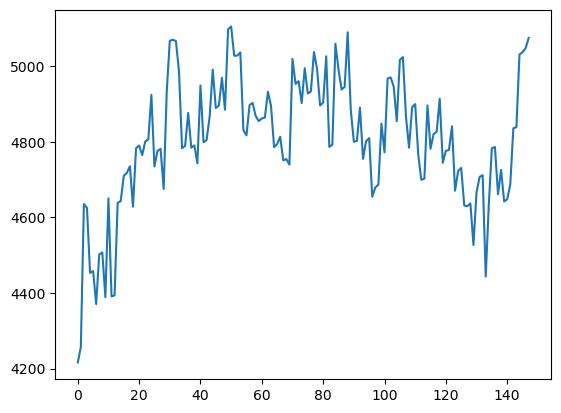

In [6]:
plt.plot(fft_ls)

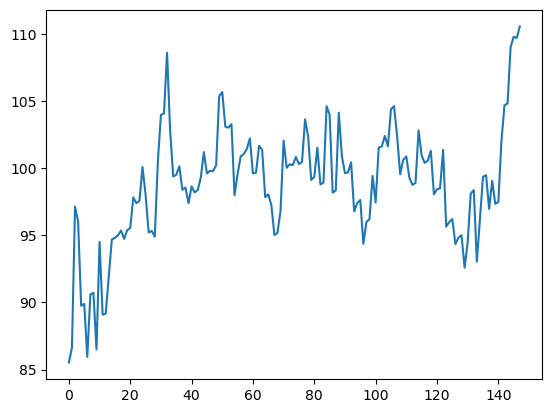

In [7]:
plt.plot(lap_ls)